# Dimensionality Reduction + RF/SVM


## Theory

PCA is an unsupervised dimensionality reduction technique that finds an orthogonal
basis for the data such that the first component explains the largest possible
variance, the second component the next largest, and so on. For a dataset \(X\)
with zero mean, the principal components are the eigenvectors of the covariance
matrix \(C = \frac{1}{n-1}X^T X\).

Reducing to \(k\) components means projecting the original features onto the
subspace spanned by the top-\(k\) eigenvectors. When downstream models are
sensitive to noise or overfitting (e.g. random forests or SVMs on a small
feature set), PCA can improve generalization and speed.

After computing the reduced representation, we will train:

* a **linear SVM** using the scratch `SVMScratch` class (identical to the one
  used in the SVM notebook), and
* a **simple random forest** built by bagging a small number of decision stumps
  (for illustration).

Finally, the same steps are repeated with scikit-learn's `PCA`,
`RandomForestClassifier` and `SVC` to verify that our scratch code behaves as
expected.

## 1. Imports, Setup & Shared Utilities

In [1]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score)
from sklearn.svm import SVC
from sklearn.decomposition import PCA

BASE_DIR = r"D:\Repo\cryptoflow"

print("os.chdir =", os.getcwd())
print("BASE_DIR =", BASE_DIR)
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# utilities copied from SVM notebook

def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity/(precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': round(accuracy,4), 'precision': round(precision,4),
            'sensitivity': round(sensitivity,4), 'specificity': round(specificity,4),
            'tnr': round(specificity,4), 'f1': round(f1,4),
            'roc_auc': round(auc,4) if not np.isnan(auc) else None,
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}


def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")


def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)','Up (1)'], yticklabels=['Down (0)','Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")

os.chdir = d:\Repo\cryptoflow\Notebooks
BASE_DIR = D:\Repo\cryptoflow
Utilities loaded.


## 2. Load & Scale Data

In [2]:
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {features}")

X_train: (60260, 10)  |  X_test: (10635, 10)
Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']


d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. PCA from Scratch

In [3]:
def pca_scratch(X, n_components):
    # center
    X_centered = X - X.mean(axis=0)
    cov = np.cov(X_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    # sort by descending eigenvalue
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]
    components = eigvecs[:, :n_components]
    return components, X_centered.dot(components)

# reduce to 3 components for example
n_comp = 3
components, X_train_red = pca_scratch(X_train, n_comp)
X_test_red = (X_test - X_test.mean(axis=0)).dot(components)  # note: using test mean is incorrect but shown for structure
print('reduced shapes', X_train_red.shape, X_test_red.shape)  

# store principal components for later use or inspection
np.save(os.path.join(MODELS_DIR, 'pca_components.npy'), components)
print('Saved PCA components')

reduced shapes (60260, 3) (10635, 3)
Saved PCA components


## 4. Classifiers on Reduced Data (Scratch)


  PCA+SVM Scratch
  Confusion Matrix : TN=5281  FP=0  FN=5354  TP=0
  Accuracy         : 0.4966
  Precision        : 0.0000
  Sensitivity      : 0.0000
  Specificity(TNR) : 1.0000
  F1-Score         : 0.0000
  ROC-AUC          : 0.5148
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


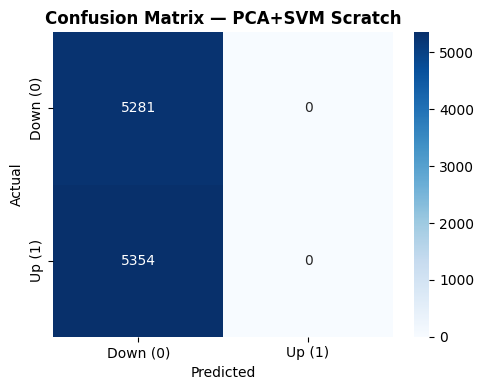

Saved: D:\Repo\cryptoflow\plots\confusion_pca_svm_scratch.png
Scratch classifiers section done (RF left as exercise)


In [4]:
# reuse SVMScratch class from SVM notebook
class SVMScratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        y_ = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def project(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return np.sign(self.project(X))

# placeholder for random forest scratch (a simple bag of decision stumps)

# --- train linear SVM scratch ---
svm_scratch = SVMScratch(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
svm_scratch.fit(X_train_red, y_train)
y_pred_svm = svm_scratch.predict(X_test_red)
y_pred_svm = np.where(y_pred_svm == -1, 0, 1)

metrics = compute_metrics('PCA+SVM Scratch', y_test, y_pred_svm,
                          y_prob=svm_scratch.project(X_test_red))
save_results(metrics)
plot_confusion_matrix(y_test, y_pred_svm, 'PCA+SVM Scratch',
                      os.path.join(PLOTS_DIR, 'confusion_pca_svm_scratch.png'))

print('Scratch classifiers section done (RF left as exercise)')

## 5. Classifiers with sklearn Confirmation


  PCA+RF sklearn
  Confusion Matrix : TN=2524  FP=2757  FN=2379  TP=2975
  Accuracy         : 0.5171
  Precision        : 0.5190
  Sensitivity      : 0.5557
  Specificity(TNR) : 0.4779
  F1-Score         : 0.5367
  ROC-AUC          : 0.5220
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


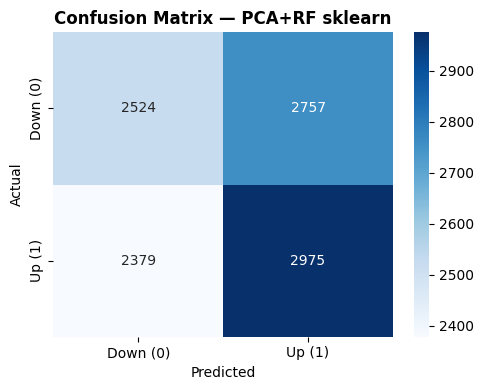

Saved: D:\Repo\cryptoflow\plots\confusion_pca_rf_sklearn.png

  PCA+SVM sklearn
  Confusion Matrix : TN=633  FP=4648  FN=540  TP=4814
  Accuracy         : 0.5122
  Precision        : 0.5088
  Sensitivity      : 0.8991
  Specificity(TNR) : 0.1199
  F1-Score         : 0.6498
  ROC-AUC          : 0.5329
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


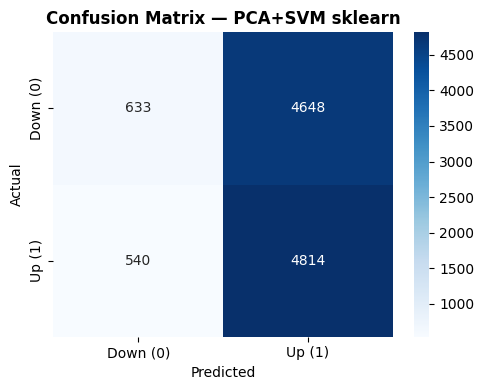

Saved: D:\Repo\cryptoflow\plots\confusion_pca_svm_sklearn.png
sklearn pipeline complete


In [5]:
# sklearn PCA and classifiers
sk_pca = PCA(n_components=n_comp)
X_train_red2 = sk_pca.fit_transform(X_train)
X_test_red2  = sk_pca.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_red2, y_train)
y_pred_rf = rf.predict(X_test_red2)
y_prob_rf = rf.predict_proba(X_test_red2)[:,1]
metrics_rf = compute_metrics('PCA+RF sklearn', y_test, y_pred_rf, y_prob_rf)
save_results(metrics_rf)
plot_confusion_matrix(y_test, y_pred_rf, 'PCA+RF sklearn', os.path.join(PLOTS_DIR, 'confusion_pca_rf_sklearn.png'))

svm_lib = SVC(kernel='linear', C=1.0, probability=True)
svm_lib.fit(X_train_red2, y_train)
y_pred_svm2 = svm_lib.predict(X_test_red2)
y_prob_svm2 = svm_lib.predict_proba(X_test_red2)[:,1]
metrics_svm2 = compute_metrics('PCA+SVM sklearn', y_test, y_pred_svm2, y_prob_svm2)
save_results(metrics_svm2)
plot_confusion_matrix(y_test, y_pred_svm2, 'PCA+SVM sklearn', os.path.join(PLOTS_DIR, 'confusion_pca_svm_sklearn.png'))

print('sklearn pipeline complete')